# Course 3 · Week 2 — Solution: Collaborative Filtering + PCA

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 5 users × 6 movies. Underlying truth: each movie has a 2-d "genre vector"
# (romance score, action score), each user has a 2-d "taste vector".
# Predicted rating = user_taste · movie_genre. Then we hide ~40% of ratings.

np.random.seed(0)
movie_features = np.array([
    [1.0, 0.0],  # m0: pure romance
    [0.9, 0.1],  # m1: mostly romance
    [0.2, 0.8],  # m2: mostly action
    [0.0, 1.0],  # m3: pure action
    [0.5, 0.5],  # m4: balanced
    [0.7, 0.3],  # m5: mostly romance
])
user_features = np.array([
    [4.0, 0.5],
    [3.5, 1.0],
    [0.5, 4.0],
    [1.0, 3.5],
    [2.0, 2.0],
])
R_full = np.clip(user_features @ movie_features.T, 0, 5)

m_users, m_items = R_full.shape
np.random.seed(42)
mask = np.random.rand(m_users, m_items) < 0.6
R_obs = np.where(mask, R_full, np.nan)
print("Observed ratings (NaN = not rated):")
print(np.round(R_obs, 2))
print(f"\n{int(mask.sum())} ratings observed, {int((~mask).sum())} hidden")
R = np.nan_to_num(R_obs, nan=0.0)  # numeric form (zeros where unrated)


Observed ratings (NaN = not rated):
[[4.    nan  nan 0.5  2.25 2.95]
 [3.5   nan  nan  nan 2.25  nan]
 [ nan 0.85 3.3  4.   2.25 1.55]
 [1.   1.25  nan 3.5  2.25 1.75]
 [2.    nan 2.   2.   2.   2.  ]]

21 ratings observed, 9 hidden


## Recap — collaborative filtering

The matrix `R` is partly observed: some users rated some movies, but most cells are blank. The goal is to predict the blanks.

The trick: assume each user has a `k`-dimensional taste vector `w_u`, each movie a `k`-dimensional feature vector `x_m`, and the rating is `w_u · x_m + b_m`. Both `w` and `x` are unknown — we learn them jointly by minimizing squared error over *observed* entries (plus regularization).

How does this even work? Multiple users rate the same movies. So if Alice and Bob both rate Movie 1, that gives the optimizer two equations involving Movie 1's vector — enough to start pinning it down. Once Movie 1's vector is roughly known, it constrains the user vectors of everyone who rated it. The two sides bootstrap each other.

Cost (squared error over rated entries + L2 regularization):

$$J = \frac{1}{2} \sum_{(u, m) \,:\, r_{um} \text{ observed}} (w_u \cdot x_m + b_m - r_{um})^2 + \frac{\lambda}{2}(\|W\|^2 + \|X\|^2)$$


**CF cost — implementation notes**\n\nThe `mask` lets us zero out unrated cells without conditional indexing — `(pred - R) * mask` is zero wherever there's no rating, so squaring and summing only counts observed entries.

In [2]:
def cf_cost(W, X, b, R, mask, lam):
    pred = W @ X.T + b
    err = (pred - R) * mask
    sq_err = float((err * err).sum() / 2)
    reg = (lam / 2) * (float((W * W).sum()) + float((X * X).sum()))
    return sq_err + reg

# Sanity
W_t = np.array([[1.0, 0.0]]); X_t = np.array([[1.0, 0.0], [0.0, 1.0]])
b_t = np.zeros(2); R_t = np.array([[1.0, 0.0]]); mask_t = np.array([[1.0, 1.0]])
assert abs(cf_cost(W_t, X_t, b_t, R_t, mask_t, lam=0.0)) < 1e-9
assert abs(cf_cost(W_t, X_t, b_t, R_t, mask_t, lam=1.0) - 1.5) < 1e-9
print("✓ cf_cost() works")


✓ cf_cost() works


**CF gradients**\n\nThe symmetry between dW and dX is satisfying: each is `error @ other_side + lambda * itself`. db sums errors per item — no regularization on biases (just like Course 1's regularized regression).

In [3]:
def cf_gradients(W, X, b, R, mask, lam):
    pred = W @ X.T + b
    err = (pred - R) * mask
    dW = err @ X + lam * W
    dX = err.T @ W + lam * X
    db = err.sum(axis=0)
    return dW, dX, db


**Training loop**\n\nGradient descent — same shape as everything we've done before. Cost drops from ~62 to ~0.5. MAE on the hidden ratings is around 0.5 stars on a 0-5 scale — pretty good for a tiny model on a tiny dataset.

Initial cost: 62.3828
Final cost: 0.5426

MAE on the 9 hidden ratings: 0.4994
  user 0, movie 1:  predicted 1.95,  true 3.65
  user 0, movie 2:  predicted 1.47,  true 1.20
  user 1, movie 1:  predicted 1.80,  true 3.25
  user 1, movie 2:  predicted 1.77,  true 1.50
  user 1, movie 3:  predicted 1.10,  true 1.00
  user 1, movie 5:  predicted 2.71,  true 2.75
  user 2, movie 0:  predicted 0.53,  true 0.50
  user 3, movie 2:  predicted 2.97,  true 3.00
  user 4, movie 1:  predicted 1.40,  true 2.00


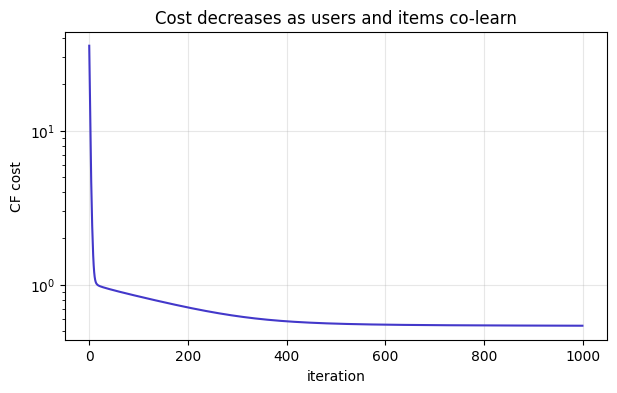

In [4]:
n_features = 2
np.random.seed(0)
W = np.random.randn(m_users, n_features) * 0.5
X = np.random.randn(m_items, n_features) * 0.5
b = np.zeros(m_items)
alpha = 0.05
lam = 0.1

print(f"Initial cost: {cf_cost(W, X, b, R, mask, lam):.4f}")
hist = []
for step in range(1000):
    dW, dX, db = cf_gradients(W, X, b, R, mask, lam)
    W -= alpha * dW; X -= alpha * dX; b -= alpha * db
    hist.append(cf_cost(W, X, b, R, mask, lam))

print(f"Final cost: {hist[-1]:.4f}")

R_pred = W @ X.T + b
hidden = ~mask
mae = float(np.abs(R_pred - R_full)[hidden].mean())
print(f"\nMAE on the {int(hidden.sum())} hidden ratings: {mae:.4f}")
for i, j in zip(*np.where(hidden)):
    print(f"  user {i}, movie {j}:  predicted {R_pred[i,j]:.2f},  true {R_full[i,j]:.2f}")

plt.figure(figsize=(7, 4))
plt.plot(hist, color="#4338ca")
plt.xlabel("iteration"); plt.ylabel("CF cost"); plt.yscale("log")
plt.title("Cost decreases as users and items co-learn")
plt.grid(alpha=0.3); plt.show()


## Recap — PCA

PCA finds the direction(s) along which data varies most. The first principal component (PC1) is the unit vector along the longest axis of the data cloud.

Computationally, PCA = SVD on centered data:

$$X = U S V^T$$

The columns of `V` (rows of `Vt` in numpy) are the principal directions. The singular values `S[k]` tell you how much variance is along the k-th direction. `S[k]^2 / sum(S^2)` is the "fraction of variance explained" by that component — you'll see this metric everywhere.

PCA today is mostly used for **visualization** (squash high-dim data to 2D for plotting). Its older use case as a compression / pre-processing step has mostly been replaced by deep learning.


**PCA via SVD**\n\nOne line: `np.linalg.svd(X_centered, full_matrices=False)`. The principal directions are rows of `Vt`. The first component captures ~97% of variance because we deliberately stretched the data along one axis.

singular values: [12.537  2.113]
explained variance ratio: [0.972 0.028]


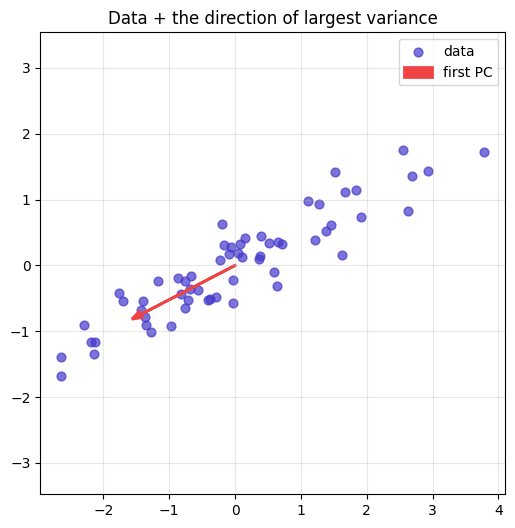

In [5]:
np.random.seed(1)
n = 60
theta = np.deg2rad(30)
T = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
X_pca = np.random.randn(n, 2) * np.array([2.0, 0.3]) @ T.T
X_pca -= X_pca.mean(axis=0)

U, S, Vt = np.linalg.svd(X_pca, full_matrices=False)
print(f"singular values: {np.round(S, 3)}")
print(f"explained variance ratio: {np.round(S**2 / (S**2).sum(), 3)}")

plt.figure(figsize=(6, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], color="#4338ca", s=40, alpha=0.7, label="data")
arrow = Vt[0] * S[0] / np.sqrt(n)
plt.arrow(0, 0, arrow[0], arrow[1], head_width=0.1, color="#ef4444", lw=2, label="first PC")
plt.axis("equal"); plt.grid(alpha=0.3); plt.legend()
plt.title("Data + the direction of largest variance")
plt.show()


## ⭐ Stretch — reconstruction\n\nProject onto the first component (a 1-D representation), then reconstruct in 2-D by `np.outer`. The reconstruction recovers ~97% of variance — the missing 3% is the across-axis noise you can't capture with a single direction.

reconstruction MSE: 0.0372
original variance:  1.3470
variance retained:  0.9724


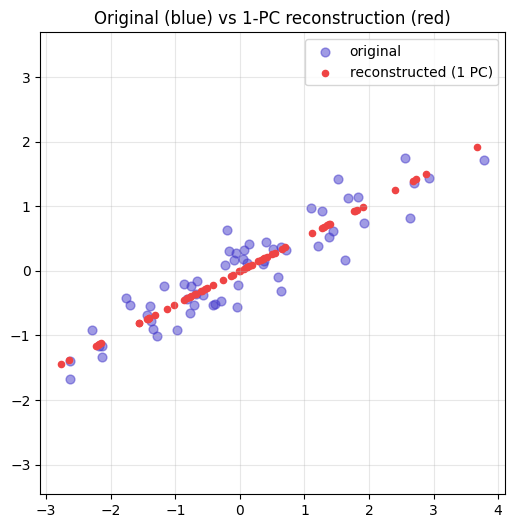

In [6]:
# Project to 1D
z = X_pca @ Vt[0]
# Reconstruct in 2D
X_recon = np.outer(z, Vt[0])
mse = float(((X_pca - X_recon)**2).mean())
print(f"reconstruction MSE: {mse:.4f}")
print(f"original variance:  {float(X_pca.var()):.4f}")
print(f"variance retained:  {1 - mse/X_pca.var():.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], color="#4338ca", s=40, alpha=0.5, label="original")
plt.scatter(X_recon[:, 0], X_recon[:, 1], color="#ef4444", s=20, label="reconstructed (1 PC)")
plt.axis("equal"); plt.grid(alpha=0.3); plt.legend()
plt.title("Original (blue) vs 1-PC reconstruction (red)")
plt.show()
